# POC_DDM_final — Classification Performance Comparison

Covers **16 models** (4 families × 4 SC levels) across two datasets, two preprocessing
variants, three curve types, and five metrics (accuracy, F1, AUC-ROC, sensitivity, specificity).

| Dimension | Values |
|---|---|
| Dataset | DDM_01_01, DDM_01_04 |
| Preprocessing | Original `POC_DDM_final`, NC-Subtract `POC_DDM_final_nc_subtract` |
| Curve type | Ori (raw), Moving Avg, Wavelet Sym8 |
| Family | CGD, CGD+Cos, CGD+Attn, CCGD-ST |
| SC level | SC0 (no SupCon), SC1, SC2, SC3 |


In [ ]:
import os, sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              recall_score, confusion_matrix)

try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass

%load_ext autoreload
%autoreload 2
import config
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [ ]:
# ── Model universe ────────────────────────────────────────────────────────────
# 4 families × 4 SC levels = 16 models

FAMILIES = ['cnn_gru_dual', 'cnn_gru_dual_cosine_recon',
            'cnn_gru_dual_attn_recon', 'ccgd_arch_poc_st']
SC_LEVELS = [0, 1, 2, 3]

# model key used as the joblib lookup suffix: y_preds_AC_<key>_
MODEL_KEY = {
    (fam, 0): fam for fam in FAMILIES
}
MODEL_KEY.update({
    ('cnn_gru_dual', 1):              'cnn_gru_dual_supcon',
    ('cnn_gru_dual_cosine_recon', 1): 'cnn_gru_dual_cosine_recon_supcon',
    ('cnn_gru_dual_attn_recon', 1):   'cnn_gru_dual_attn_recon_supcon',
    ('ccgd_arch_poc_st', 1):          'ccgd_arch_poc_st_sc1',
    ('cnn_gru_dual', 2):              'cnn_gru_dual_supcon2',
    ('cnn_gru_dual_cosine_recon', 2): 'cnn_gru_dual_cosine_recon_supcon2',
    ('cnn_gru_dual_attn_recon', 2):   'cnn_gru_dual_attn_recon_supcon2',
    ('ccgd_arch_poc_st', 2):          'ccgd_arch_poc_st_sc2',
    ('cnn_gru_dual', 3):              'cnn_gru_dual_supcon3',
    ('cnn_gru_dual_cosine_recon', 3): 'cnn_gru_dual_cosine_recon_supcon3',
    ('cnn_gru_dual_attn_recon', 3):   'cnn_gru_dual_attn_recon_supcon3',
    ('ccgd_arch_poc_st', 3):          'ccgd_arch_poc_st_sc3',
})

MODELS = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
MODEL_TO_FAMILY = {MODEL_KEY[(fam, sc)]: fam for sc in SC_LEVELS for fam in FAMILIES}
MODEL_TO_SC = {MODEL_KEY[(fam, sc)]: sc for sc in SC_LEVELS for fam in FAMILIES}

# ── Paths ─────────────────────────────────────────────────────────────────────
TARGET_FOLDERS = [
    'D20260731_E00_C00_F4500KHz_U_DDM_01_01',
    'D20260731_E00_C00_F4500KHz_U_DDM_01_04',
]
PREP_DIRS = {
    'original':    '/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final',
    'nc_subtract': '/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract',
}
CURVE_JLIB = {
    'ori':     'Ori Curves',
    'avg':     'Ori Curves Avg',
    'wavelet': 'Ori Curves Wavelet Sym8',
}

def short_name(folder):
    return folder.split('_U_', 1)[1]

DATASET_NAMES = [short_name(f) for f in TARGET_FOLDERS]

# ── Labels ────────────────────────────────────────────────────────────────────
FAMILY_LABELS = {
    'cnn_gru_dual':              'CGD',
    'cnn_gru_dual_cosine_recon': 'CGD+Cos',
    'cnn_gru_dual_attn_recon':   'CGD+Attn',
    'ccgd_arch_poc_st':          'CCGD-ST',
}
SC_LABELS   = {0: 'SC0', 1: 'SC1', 2: 'SC2', 3: 'SC3'}
PREP_LABELS = {'original': 'Original', 'nc_subtract': 'NC-Subtract'}
CURVE_LABELS = {'ori': 'Ori (raw)', 'avg': 'Moving Avg', 'wavelet': 'Wavelet Sym8'}
METRIC_LABELS = {
    'accuracy':    'Accuracy',
    'f1':          'F1 macro',
    'auc':         'AUC-ROC',
    'sensitivity': 'Sensitivity',
    'specificity': 'Specificity',
}
METRICS = list(METRIC_LABELS)

# ── Colors ────────────────────────────────────────────────────────────────────
FAMILY_COLORS = {
    'cnn_gru_dual':              '#1f77b4',
    'cnn_gru_dual_cosine_recon': '#2ca02c',
    'cnn_gru_dual_attn_recon':   '#d62728',
    'ccgd_arch_poc_st':          '#9467bd',
}
SC_MARKERS = {0: 'o', 1: 's', 2: '^', 3: 'D'}
SC_LINES   = {0: '-', 1: '--', 2: ':', 3: '-.'}
PREP_COLORS  = {'original': '#4393c3', 'nc_subtract': '#d6604d'}
CURVE_COLORS = {'ori': '#4393c3', 'avg': '#e08c00', 'wavelet': '#1a9850'}

MODEL_ROW_LABEL = {
    MODEL_KEY[(fam, sc)]: f'{SC_LABELS[sc]}  {FAMILY_LABELS[fam]}'
    for sc in SC_LEVELS for fam in FAMILIES
}

print(f"{len(MODELS)} models defined.")
print("  " + "\n  ".join(MODELS))


16 models defined.
  cnn_gru_dual
  cnn_gru_dual_cosine_recon
  cnn_gru_dual_attn_recon
  ccgd_arch_poc_st
  cnn_gru_dual_supcon
  cnn_gru_dual_cosine_recon_supcon
  cnn_gru_dual_attn_recon_supcon
  ccgd_arch_poc_st_sc1
  cnn_gru_dual_supcon2
  cnn_gru_dual_cosine_recon_supcon2
  cnn_gru_dual_attn_recon_supcon2
  ccgd_arch_poc_st_sc2
  cnn_gru_dual_supcon3
  cnn_gru_dual_cosine_recon_supcon3
  cnn_gru_dual_attn_recon_supcon3
  ccgd_arch_poc_st_sc3


In [ ]:
def compute_metrics(perf, model_key):
    """Return dict with accuracy/f1/auc/sensitivity/specificity, or None if missing."""
    pred_k = f'y_preds_AC_{model_key}_'
    prob_k = f'y_probs_AC_{model_key}_'
    if pred_k not in perf:
        return None

    y_true  = np.concatenate(perf['y_trues_'])
    y_pred  = np.concatenate(perf[pred_k])
    y_probs = np.concatenate(perf[prob_k]) if prob_k in perf else None
    n_cls   = len(np.unique(y_true))

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)

    if y_probs is not None and n_cls > 1:
        try:
            auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    # Specificity = TN/(TN+FP) per class, macro-averaged
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    return {'accuracy': acc, 'f1': f1, 'auc': auc,
            'sensitivity': sens, 'specificity': float(np.mean(specs))}


In [ ]:
def load_all():
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        for prep, base_dir in PREP_DIRS.items():
            path = Path(base_dir) / folder / 'classification_performances.joblib'
            if not path.exists():
                print(f'[WARN] missing {path}')
                continue
            data = joblib.load(path)
            for curve, jlib_key in CURVE_JLIB.items():
                perf = data.get(jlib_key, {}).get('Native', {}).get(None)
                if perf is None:
                    continue
                for model in MODELS:
                    m = compute_metrics(perf, model)
                    if m is None:
                        continue
                    rows.append(dict(dataset=dataset, preprocessing=prep,
                                     curve_type=curve, model=model,
                                     family=MODEL_TO_FAMILY[model],
                                     sc_level=MODEL_TO_SC[model], **m))
    return pd.DataFrame(rows)

df = load_all()
print(f"Loaded {len(df)} rows  |  "
      f"{df.dataset.nunique()} datasets  "
      f"{df.preprocessing.nunique()} preprocessing  "
      f"{df.curve_type.nunique()} curve types  "
      f"{df.model.nunique()} models")
df.head(4)


Loaded 161 rows  |  2 datasets  2 preprocessing  3 curve types  16 models


,dataset,preprocessing,curve_type,model,family,sc_level,accuracy,f1,auc,sensitivity,specificity
0,DDM_01_01,original,ori,cnn_gru_dual,cnn_gru_dual,0,0.867631,0.850364,0.980576,0.846569,0.975926
1,DDM_01_01,original,ori,cnn_gru_dual_cosine_recon,cnn_gru_dual_cosine_recon,0,0.995713,0.995819,0.999958,0.997467,0.999297
2,DDM_01_01,original,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,0.998928,0.998942,0.999999,0.998942,0.999804
3,DDM_01_01,original,ori,ccgd_arch_poc_st,ccgd_arch_poc_st,0,0.863880,0.842956,0.980023,0.837451,0.974961


In [ ]:
df

,dataset,preprocessing,curve_type,model,family,sc_level,accuracy,f1,auc,sensitivity,specificity
0,DDM_01_01,original,ori,cnn_gru_dual,cnn_gru_dual,0,0.867631,0.850364,0.980576,0.846569,0.975926
1,DDM_01_01,original,ori,cnn_gru_dual_cosine_recon,cnn_gru_dual_cosine_recon,0,0.995713,0.995819,0.999958,0.997467,0.999297
2,DDM_01_01,original,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,0.998928,0.998942,0.999999,0.998942,0.999804
3,DDM_01_01,original,ori,ccgd_arch_poc_st,ccgd_arch_poc_st,0,0.863880,0.842956,0.980023,0.837451,0.974961
4,DDM_01_01,original,ori,cnn_gru_dual_supcon,cnn_gru_dual,1,0.869239,0.852675,0.980047,0.846168,0.976026
...,...,...,...,...,...,...,...,...,...,...,...
156,DDM_01_04,nc_subtract,wavelet,ccgd_arch_poc_st_sc2,ccgd_arch_poc_st,2,0.774461,0.730058,0.961562,0.738134,0.960347
157,DDM_01_04,nc_subtract,wavelet,cnn_gru_dual_supcon3,cnn_gru_dual,3,0.777778,0.738777,0.961211,0.742798,0.960896
158,DDM_01_04,nc_subtract,wavelet,cnn_gru_dual_cosine_recon_supcon3,cnn_gru_dual_cosine_recon,3,0.970702,0.972003,0.998650,0.970814,0.994660
159,DDM_01_04,nc_subtract,wavelet,cnn_gru_dual_attn_recon_supcon3,cnn_gru_dual_attn_recon,3,0.993367,0.993587,0.999903,0.992607,0.998768


In [ ]:
expected = len(MODELS)
check = (df.groupby(['dataset','preprocessing','curve_type'])
           .size()
           .reset_index(name='n')
           .assign(expected=expected, ok=lambda x: x.n == x.expected))
missing = check[~check.ok]
if missing.empty:
    print("All combinations fully populated.")
else:
    print("[!] Incomplete combinations:")
    display(missing)


[!] Incomplete combinations:


,dataset,preprocessing,curve_type,n,expected,ok
0,DDM_01_01,nc_subtract,avg,4,16,False
1,DDM_01_01,nc_subtract,ori,9,16,False
2,DDM_01_01,nc_subtract,wavelet,4,16,False


## 1 · Summary table
Full metrics pivot for a chosen (dataset, preprocessing, curve_type).
Change the `_FILTER_*` variables to explore other slices.

In [ ]:
_FILTER_DATASET = 'DDM_01_04'   # or 'DDM_01_01'
# _FILTER_CURVE   = 'ori'         # 'ori' | 'avg' | 'wavelet'

for _FILTER_CURVE in ['ori', 'avg', 'wavelet']:
    _sub = df[(df.dataset == _FILTER_DATASET) & (df.curve_type == _FILTER_CURVE)].copy()
    _sub['SC']     = _sub.sc_level.map(SC_LABELS)
    _sub['Family'] = _sub.family.map(FAMILY_LABELS)

    # Pivot: rows = (SC, Family), outer cols = metric, inner cols = preprocessing
    _pivot = (
        _sub.set_index(['SC', 'Family', 'preprocessing'])[METRICS]
        .stack()
        .rename('val')
        .reset_index()
        .pivot_table(index=['SC', 'Family'],
                    columns=['level_3', 'preprocessing'],
                    values='val')
    )

    _prep_order   = ['original', 'nc_subtract']
    _metric_order = METRICS
    _pivot = _pivot.reindex(
        columns=pd.MultiIndex.from_product([_metric_order, _prep_order])
    )
    _pivot.columns = pd.MultiIndex.from_tuples(
        [(METRIC_LABELS[m], PREP_LABELS[p]) for m, p in _pivot.columns]
    )

    # Preserve SC / Family display order
    _sc_order  = [SC_LABELS[s]  for s in SC_LEVELS]
    _fam_order = [FAMILY_LABELS[f] for f in FAMILIES]
    _pivot = _pivot.loc[
        pd.MultiIndex.from_product([_sc_order, _fam_order], names=['SC', 'Family'])
    ]

    _pivot_pct = (_pivot * 100).round(2)

    # Per-column green gradient
    def _col_gradient(col):
        mn, mx = col.min(), col.max()
        rng = mx - mn if mx > mn else 1e-9
        return [f'background-color: rgba(26,152,80,{0.12 + 0.72*(v - mn)/rng:.2f})'
                for v in col]

    # Bold separator after every 2nd column (between metric groups)
    def _metric_borders(styler):
        for mi in range(len(_metric_order) - 1):
            last_col = (mi + 1) * len(_prep_order) - 1
            styler = styler.set_properties(
                subset=pd.IndexSlice[:, _pivot_pct.columns[last_col]],
                **{'border-right': '2px solid #555'}
            )
        return styler

    styled = (
        _pivot_pct.style
        .apply(_col_gradient, axis=0)
        .format("{:.2f}%")
        .set_caption(
            f"{_FILTER_DATASET}  |  {CURVE_LABELS[_FILTER_CURVE]}  "
            f"|  columns: metric → Original vs NC-Subtract"
        )
    )
    styled = _metric_borders(styled)
    display(styled)

: 

Best so far: CGD + Cross Attn

## 2 · Master heatmap — all models × all metrics
Rows = models (grouped SC0→SC3, family order within each), columns = metrics.
Each configuration is one heatmap; the function accepts any (dataset, prep, curve_type) combo.

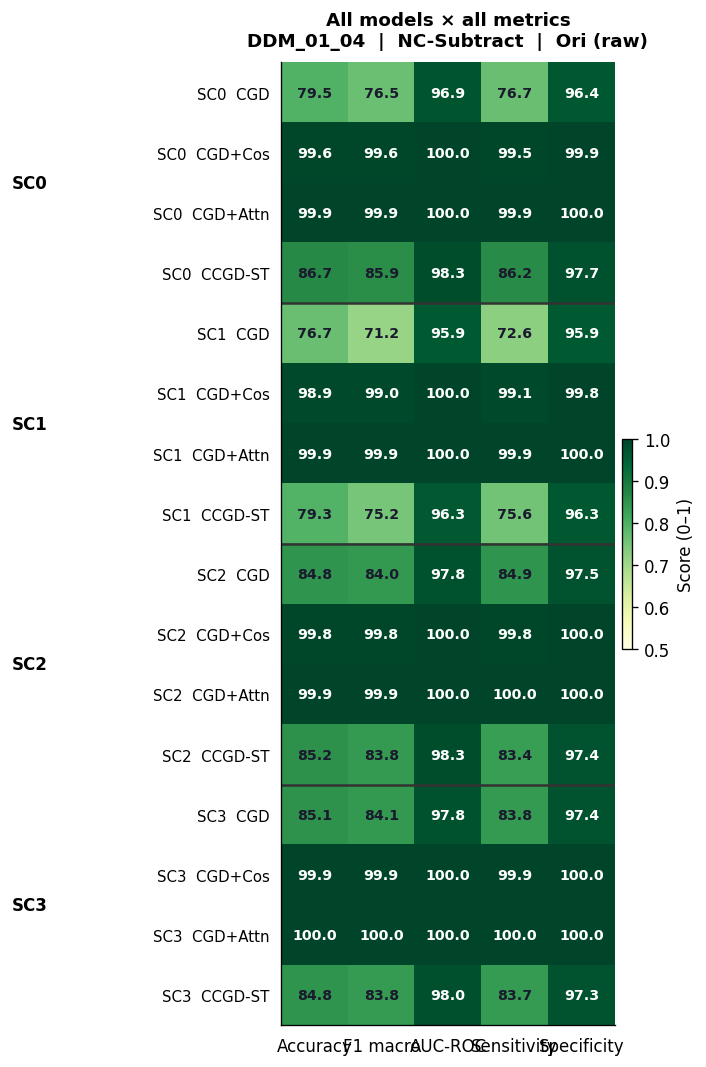

In [ ]:
def plot_master_heatmap(df, dataset, prep, curve,
                        title_suffix='', figsize=(10, 9)):
    sub = df[(df.dataset == dataset) &
             (df.preprocessing == prep) &
             (df.curve_type == curve)]
    if sub.empty:
        print(f"No data for ({dataset}, {prep}, {curve})")
        return

    # Build row order: SC0 CGD…, SC1 CGD…, …
    row_order = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
    row_labels = [MODEL_ROW_LABEL[m] for m in row_order]
    col_labels  = [METRIC_LABELS[m] for m in METRICS]

    mat = np.full((len(row_order), len(METRICS)), np.nan)
    for ri, model in enumerate(row_order):
        row = sub[sub.model == model]
        if row.empty:
            continue
        for ci, metric in enumerate(METRICS):
            mat[ri, ci] = row[metric].iloc[0]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat, cmap='YlGn', vmin=0.5, vmax=1.0, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Score (0–1)')

    # Cell text
    for ri in range(len(row_order)):
        for ci in range(len(METRICS)):
            v = mat[ri, ci]
            if np.isnan(v):
                ax.text(ci, ri, 'N/A', ha='center', va='center',
                        fontsize=8, color='#888888')
            else:
                txt_color = 'white' if v > 0.87 else '#1a1a2e'
                ax.text(ci, ri, f'{v*100:.1f}', ha='center', va='center',
                        fontsize=8.5, fontweight='bold', color=txt_color)

    # SC-group separators (after every 4 rows)
    for sep in [4, 8, 12]:
        ax.axhline(sep - 0.5, color='#333333', linewidth=1.5)

    # SC-level left annotations
    for si, sc in enumerate(SC_LEVELS):
        mid_row = si * 4 + 1.5
        ax.text(-0.7, mid_row, SC_LABELS[sc], ha='right', va='center',
                fontsize=10, fontweight='bold', transform=ax.get_yaxis_transform())

    ax.set_xticks(range(len(METRICS)))
    ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.tick_params(left=False, bottom=False)
    ax.set_title(
        f'All models × all metrics\n'
        f'{dataset}  |  {PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}'
        + (f'  |  {title_suffix}' if title_suffix else ''),
        fontsize=11, fontweight='bold', pad=10
    )
    ax.grid(False)
    fig.tight_layout(rect=[0.08, 0, 1, 1])
    plt.show()


plot_master_heatmap(df, 'DDM_01_04', 'nc_subtract', 'ori')


### 2b · Side-by-side: Original vs NC-Subtract


/tmp/ipykernel_1373618/35354567.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.07, 0, 1, 1])


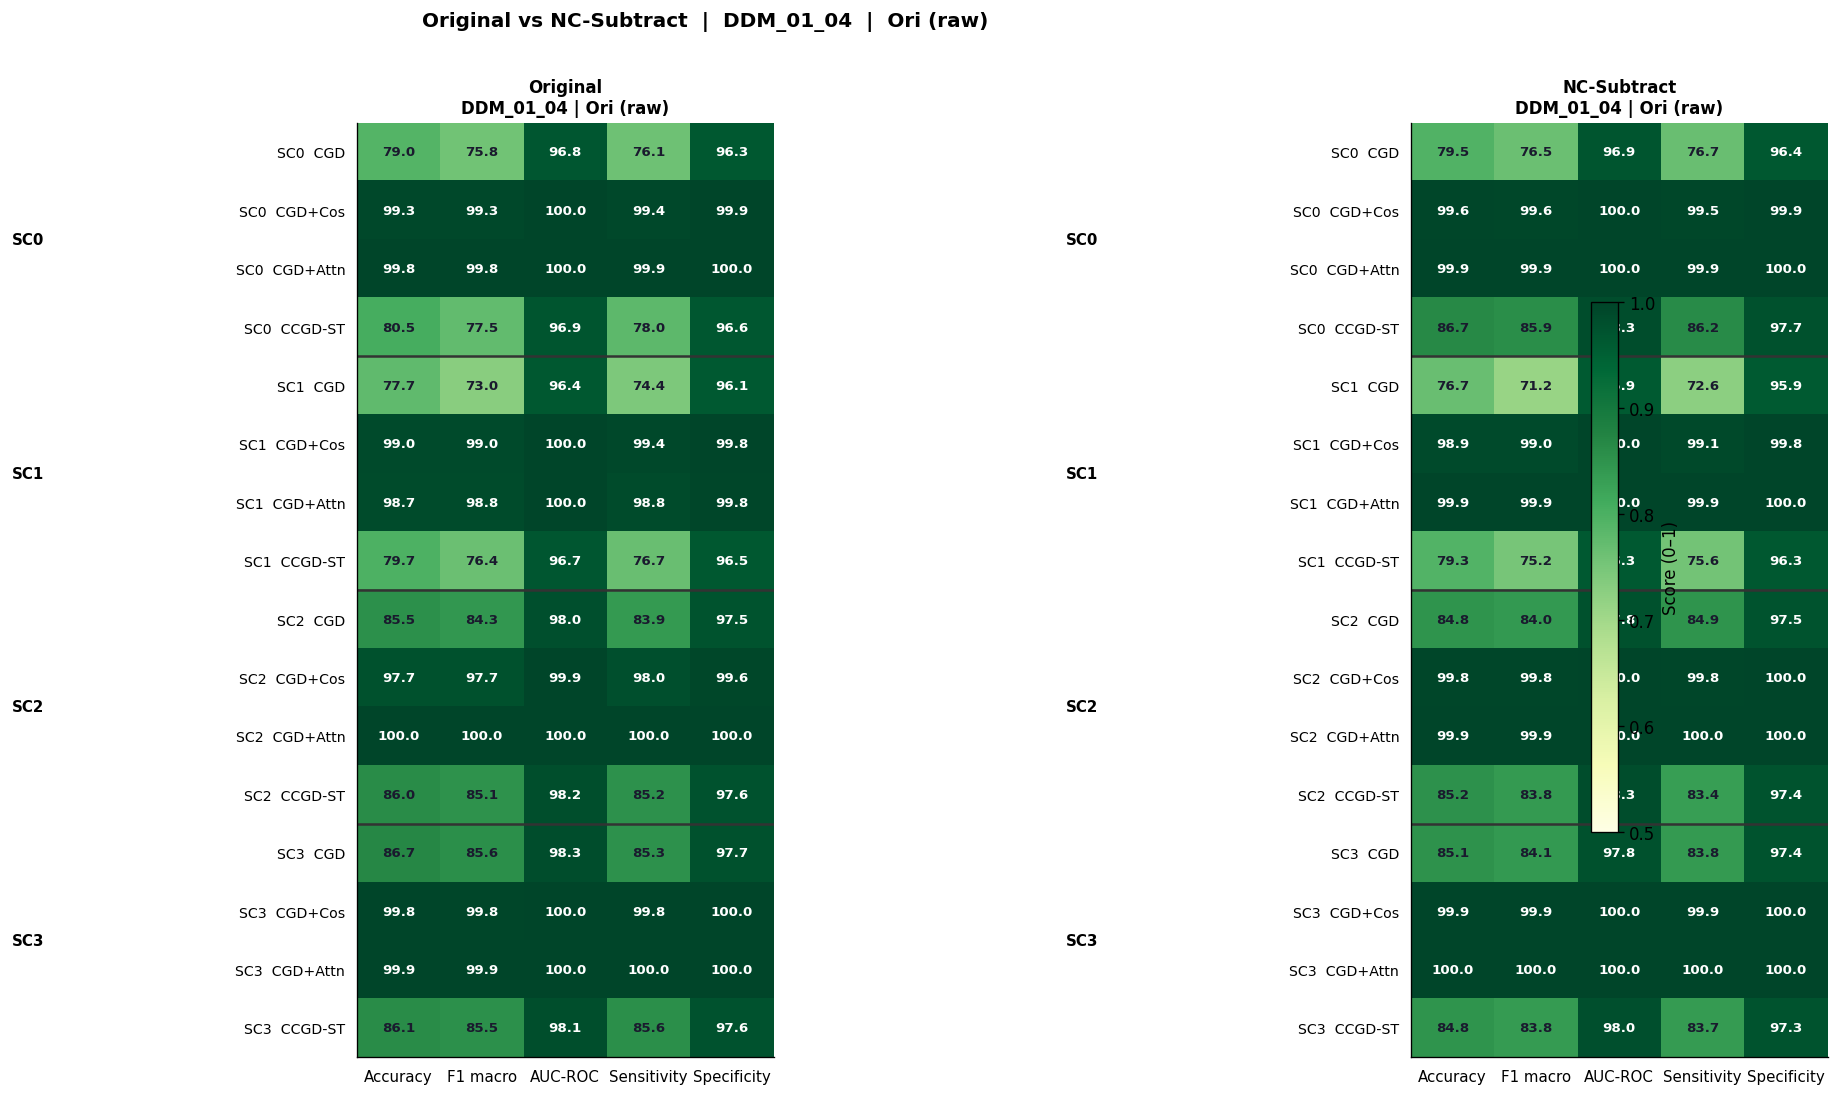

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(19, 9))

def _heatmap_ax(ax, df, dataset, prep, curve):
    sub = df[(df.dataset == dataset) & (df.preprocessing == prep) & (df.curve_type == curve)]
    row_order = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
    row_labels = [MODEL_ROW_LABEL[m] for m in row_order]
    col_labels  = [METRIC_LABELS[m] for m in METRICS]
    mat = np.full((len(row_order), len(METRICS)), np.nan)
    for ri, model in enumerate(row_order):
        row = sub[sub.model == model]
        if not row.empty:
            for ci, metric in enumerate(METRICS):
                mat[ri, ci] = row[metric].iloc[0]

    im = ax.imshow(mat, cmap='YlGn', vmin=0.5, vmax=1.0, aspect='auto')
    for ri in range(len(row_order)):
        for ci in range(len(METRICS)):
            v = mat[ri, ci]
            if not np.isnan(v):
                txt_color = 'white' if v > 0.87 else '#1a1a2e'
                ax.text(ci, ri, f'{v*100:.1f}', ha='center', va='center',
                        fontsize=8, fontweight='bold', color=txt_color)
            else:
                ax.text(ci, ri, 'N/A', ha='center', va='center',
                        fontsize=8, color='#888888')
    for sep in [4, 8, 12]:
        ax.axhline(sep - 0.5, color='#333333', linewidth=1.5)
    for si, sc in enumerate(SC_LEVELS):
        ax.text(-0.75, si * 4 + 1.5, SC_LABELS[sc], ha='right', va='center',
                fontsize=9, fontweight='bold', transform=ax.get_yaxis_transform())
    ax.set_xticks(range(len(METRICS)))
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(row_labels, fontsize=8.5)
    ax.tick_params(left=False, bottom=False)
    ax.set_title(f'{PREP_LABELS[prep]}\n{dataset} | {CURVE_LABELS[curve]}',
                 fontsize=10, fontweight='bold')
    ax.grid(False)
    return im

_COMPARE_DATASET = 'DDM_01_04'
_COMPARE_CURVE   = 'ori'

im = _heatmap_ax(axes[0], df, _COMPARE_DATASET, 'original', _COMPARE_CURVE)
_heatmap_ax(axes[1], df, _COMPARE_DATASET, 'nc_subtract', _COMPARE_CURVE)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label='Score (0–1)')
fig.suptitle(f'Original vs NC-Subtract  |  {_COMPARE_DATASET}  |  {CURVE_LABELS[_COMPARE_CURVE]}',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout(rect=[0.07, 0, 1, 1])
plt.show()


## 3 · SC level progression
How do metrics change from SC0 → SC1 → SC2 → SC3 for each model family?
One subplot per metric, lines = families. Fix dataset / preprocessing / curve type below.

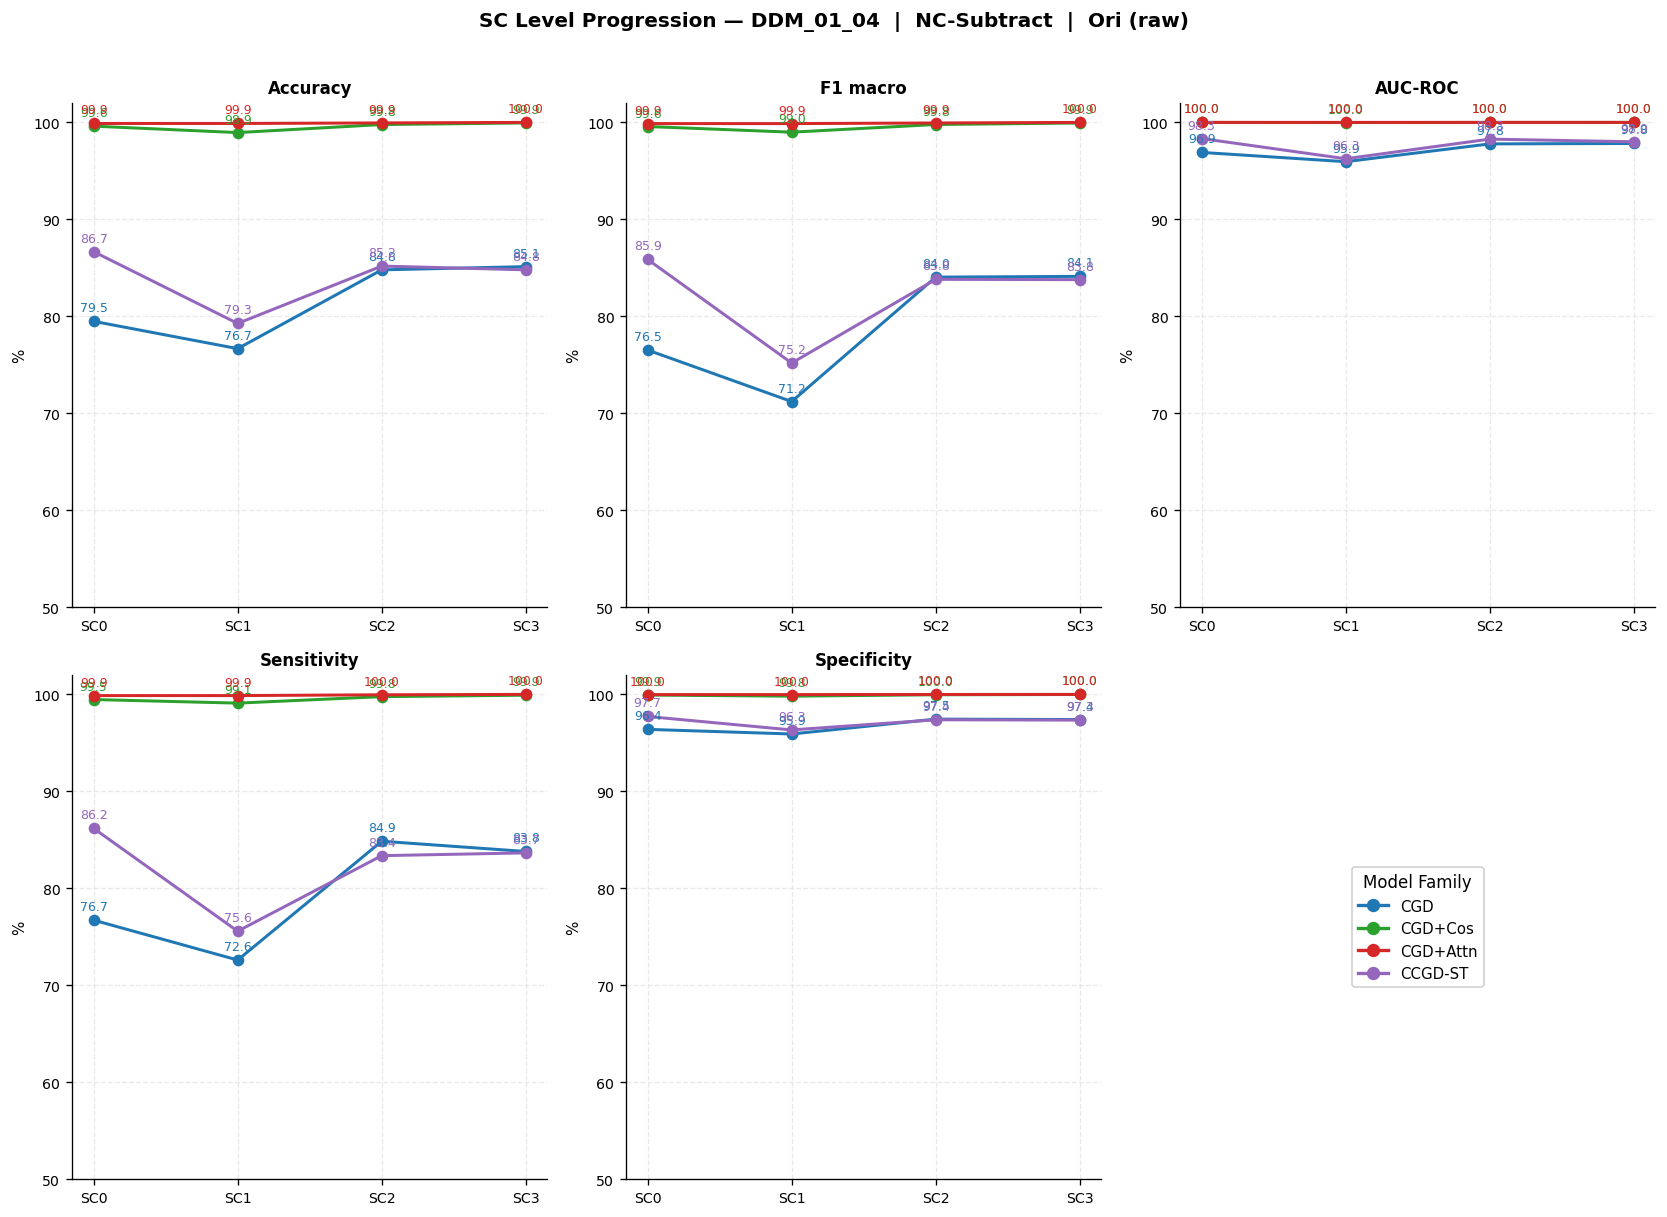

In [ ]:
def plot_sc_progression(df, dataset, prep, curve, figsize=(14, 10)):
    sub = df[(df.dataset == dataset) &
             (df.preprocessing == prep) &
             (df.curve_type == curve)]

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    x = np.array(SC_LEVELS)

    for ai, metric in enumerate(METRICS):
        ax = axes[ai]
        for fam in FAMILIES:
            ys = []
            for sc in SC_LEVELS:
                key = MODEL_KEY[(fam, sc)]
                row = sub[sub.model == key]
                ys.append(row[metric].iloc[0] if not row.empty else np.nan)
            ys = np.array(ys) * 100  # → percentage

            ax.plot(x, ys, color=FAMILY_COLORS[fam], linewidth=1.8,
                    linestyle='-', marker='o', markersize=6,
                    label=FAMILY_LABELS[fam])
            # Annotate endpoints
            for xi, yi in zip(x, ys):
                if not np.isnan(yi):
                    ax.annotate(f'{yi:.1f}', (xi, yi),
                                textcoords='offset points', xytext=(0, 6),
                                ha='center', fontsize=7.5, color=FAMILY_COLORS[fam])

        ax.set_title(METRIC_LABELS[metric], fontsize=10, fontweight='bold')
        ax.set_xticks(SC_LEVELS)
        ax.set_xticklabels([SC_LABELS[sc] for sc in SC_LEVELS])
        ax.set_ylabel('%', fontsize=9)
        ax.set_ylim(min(50, ax.get_ylim()[0] - 2), 102)
        ax.tick_params(labelsize=8.5)

    # Legend in the 6th (empty) subplot
    axes[-1].axis('off')
    handles = [plt.Line2D([0], [0], color=FAMILY_COLORS[fam], linewidth=2,
                           marker='o', markersize=7, label=FAMILY_LABELS[fam])
               for fam in FAMILIES]
    axes[-1].legend(handles=handles, title='Model Family',
                    title_fontsize=10, fontsize=9, loc='center',
                    framealpha=0.9, edgecolor='#cccccc')

    fig.suptitle(
        f'SC Level Progression — {dataset}  |  '
        f'{PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}',
        fontsize=12, fontweight='bold', y=1.01
    )
    fig.tight_layout()
    plt.show()


plot_sc_progression(df, 'DDM_01_04', 'nc_subtract', 'ori')


### 3b · SC progression: both datasets side-by-side, one metric at a time


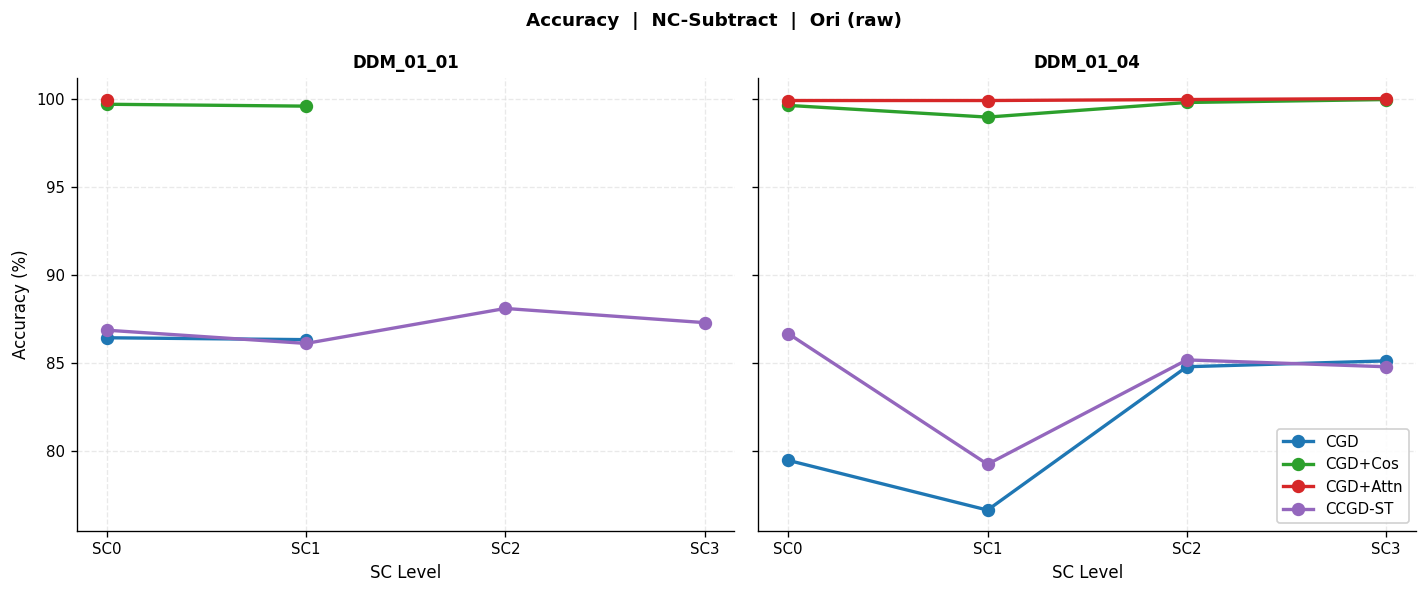

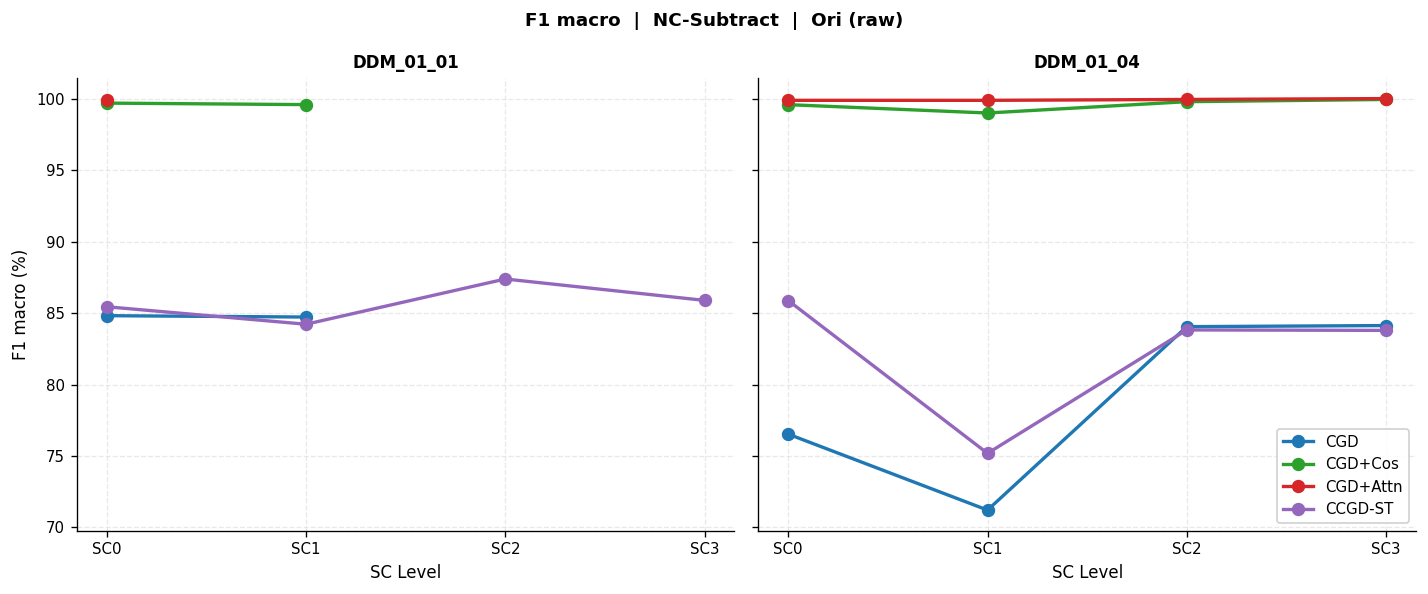

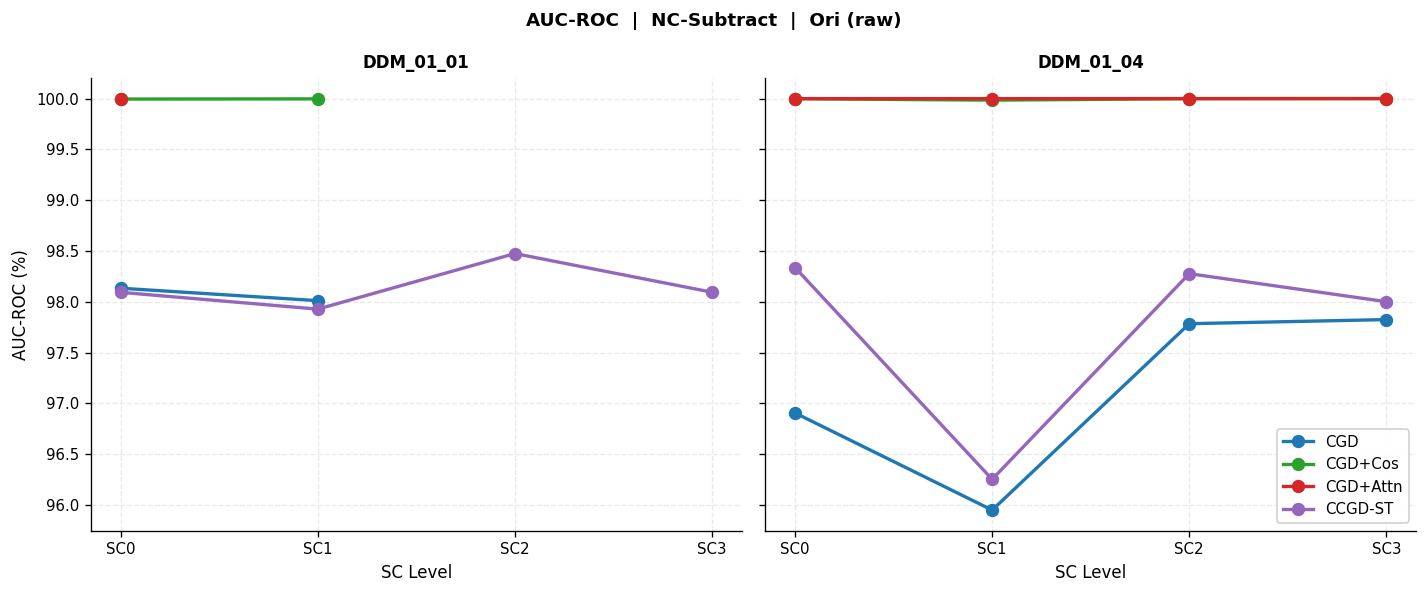

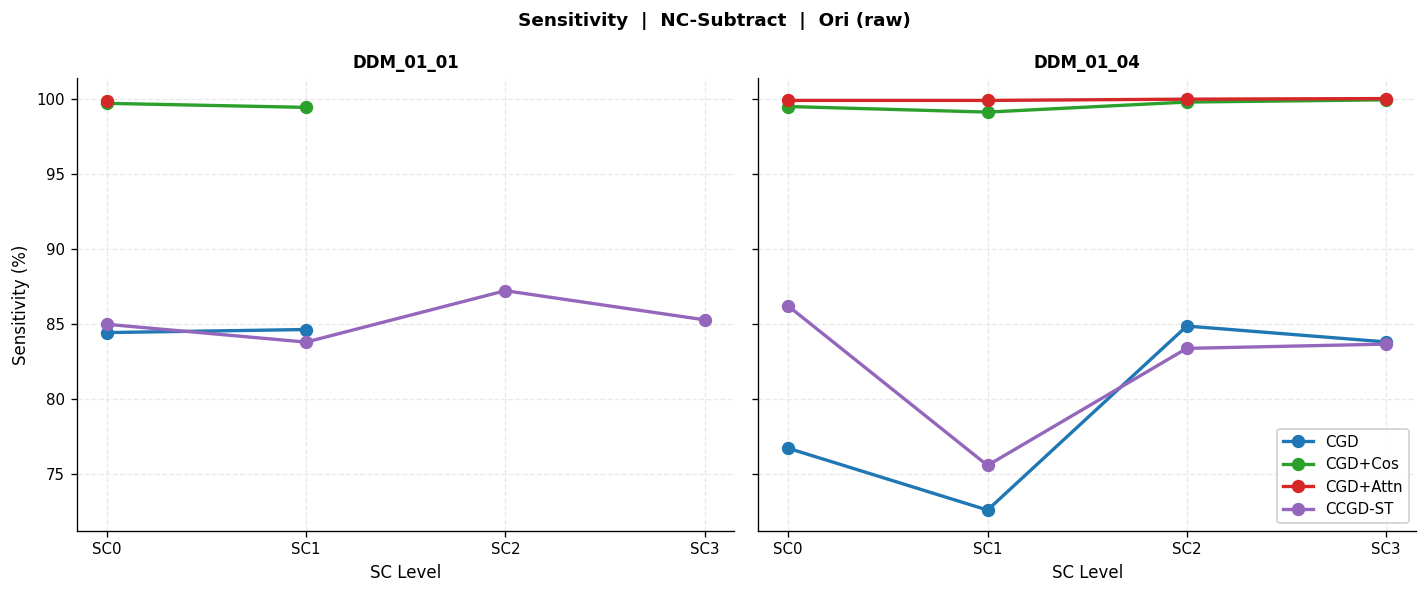

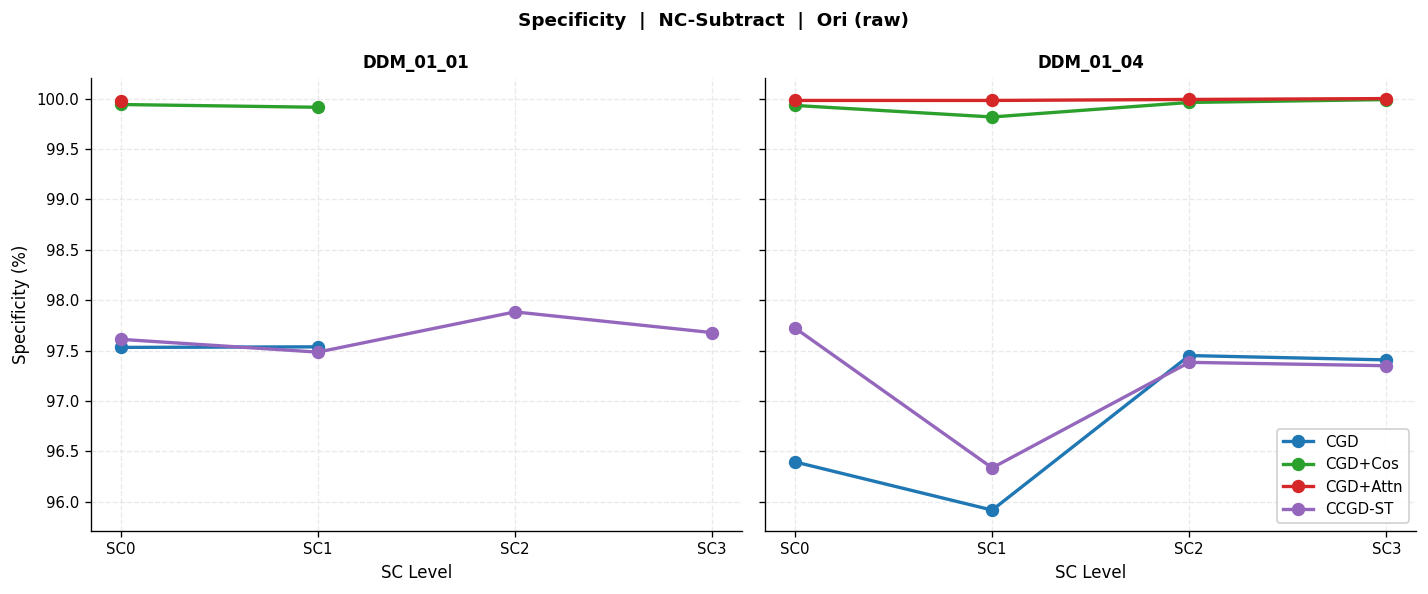

In [ ]:
def plot_sc_by_dataset(df, prep, curve, metric='accuracy'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    x = np.array(SC_LEVELS)

    for ax, dataset in zip(axes, DATASET_NAMES):
        sub = df[(df.dataset == dataset) &
                 (df.preprocessing == prep) &
                 (df.curve_type == curve)]
        for fam in FAMILIES:
            ys = np.array([
                (sub[sub.model == MODEL_KEY[(fam, sc)]][metric].iloc[0]
                 if not sub[sub.model == MODEL_KEY[(fam, sc)]].empty else np.nan)
                for sc in SC_LEVELS
            ]) * 100

            ax.plot(x, ys, color=FAMILY_COLORS[fam], linewidth=2,
                    marker='o', markersize=7, label=FAMILY_LABELS[fam])

        ax.set_title(dataset, fontsize=10, fontweight='bold')
        ax.set_xticks(SC_LEVELS)
        ax.set_xticklabels([SC_LABELS[sc] for sc in SC_LEVELS])
        ax.set_xlabel('SC Level')
        ax.tick_params(labelsize=9)
        if ax is axes[0]:
            ax.set_ylabel(f'{METRIC_LABELS[metric]} (%)', fontsize=10)

    handles = [plt.Line2D([0], [0], color=FAMILY_COLORS[f], linewidth=2,
                           marker='o', markersize=7, label=FAMILY_LABELS[f])
               for f in FAMILIES]
    axes[1].legend(handles=handles, fontsize=9, loc='lower right', framealpha=0.9)
    fig.suptitle(f'{METRIC_LABELS[metric]}  |  {PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}',
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()

# Iterate all metrics
for _metric in METRICS:
    plot_sc_by_dataset(df, 'nc_subtract', 'ori', metric=_metric)


## 4 · Preprocessing comparison: Original vs NC-Subtract
Delta heatmap shows NC-Subtract minus Original (green = NC-Subtract wins, red = Original wins).


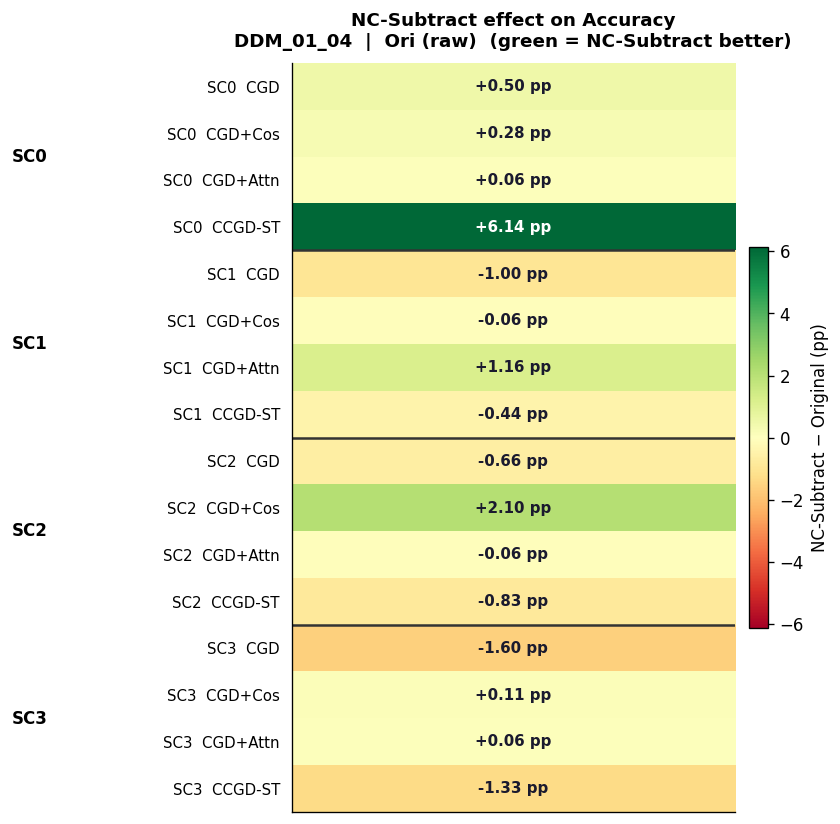

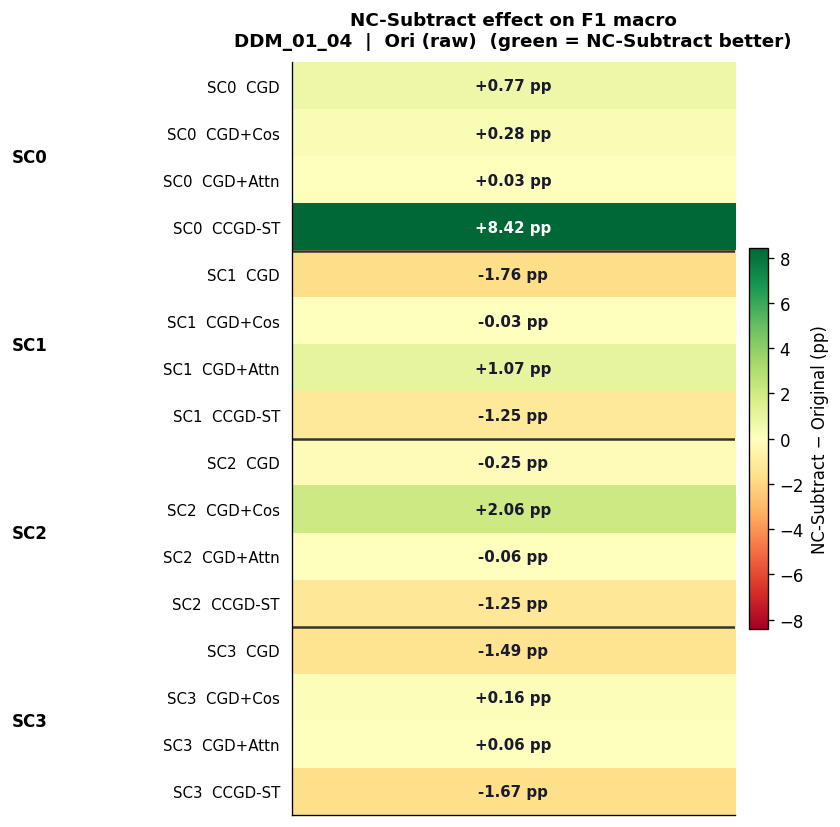

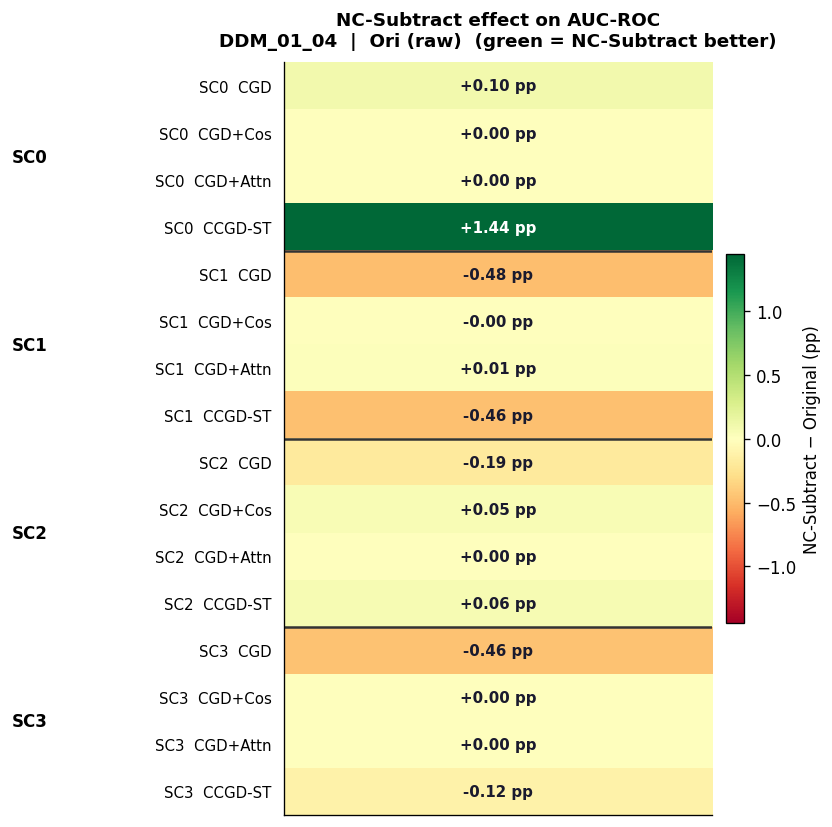

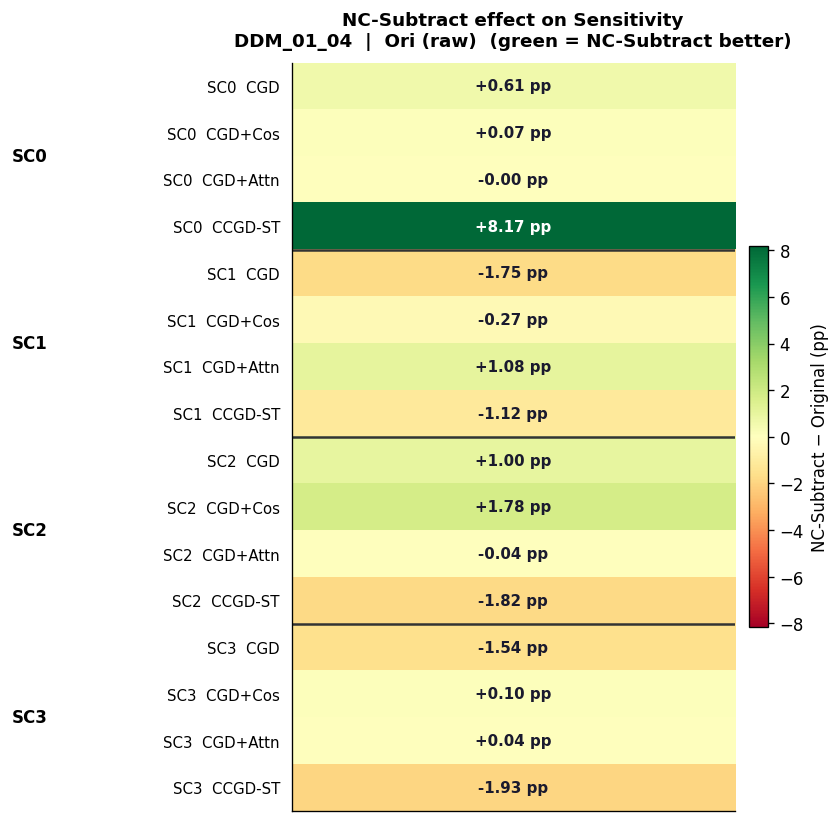

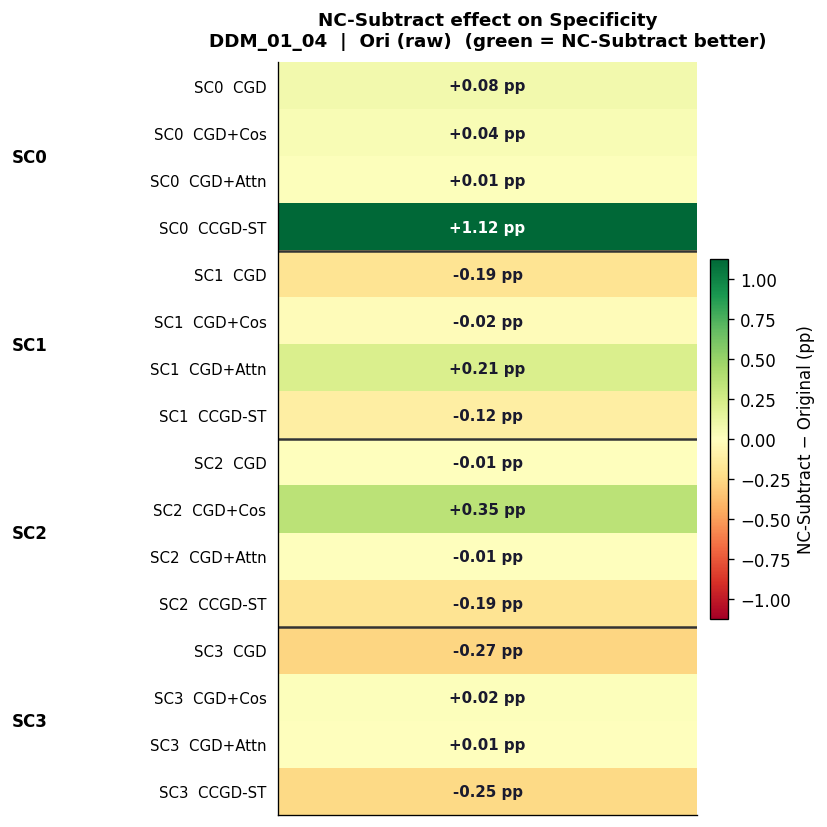

In [ ]:
def plot_preprocessing_delta(df, dataset, curve, metric='accuracy', figsize=(10, 7)):
    """Diverging heatmap: NC-Subtract score minus Original score."""
    row_order = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]

    orig = df[(df.dataset == dataset) & (df.preprocessing == 'original') & (df.curve_type == curve)]
    nc   = df[(df.dataset == dataset) & (df.preprocessing == 'nc_subtract') & (df.curve_type == curve)]

    deltas = []
    for model in row_order:
        o = orig[orig.model == model][metric]
        n = nc[nc.model == model][metric]
        d = (n.iloc[0] - o.iloc[0]) * 100 if not o.empty and not n.empty else np.nan
        deltas.append(d)
    deltas = np.array(deltas)

    bound = max(np.nanmax(np.abs(deltas)), 0.1)
    fig, ax = plt.subplots(figsize=figsize)
    mat = deltas[:, np.newaxis]
    im = ax.imshow(mat, cmap='RdYlGn', vmin=-bound, vmax=bound, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03,
                 label='NC-Subtract − Original (pp)')

    row_labels = [MODEL_ROW_LABEL[m] for m in row_order]
    for ri, (label, d) in enumerate(zip(row_labels, deltas)):
        txt = f'{d:+.2f} pp' if not np.isnan(d) else 'N/A'
        col = 'white' if abs(d) > bound * 0.6 else '#1a1a2e'
        ax.text(0, ri, txt, ha='center', va='center',
                fontsize=9, fontweight='bold', color=col)

    for sep in [4, 8, 12]:
        ax.axhline(sep - 0.5, color='#333333', linewidth=1.5)
    for si, sc in enumerate(SC_LEVELS):
        ax.text(-0.55, si * 4 + 1.5, SC_LABELS[sc], ha='right', va='center',
                fontsize=10, fontweight='bold', transform=ax.get_yaxis_transform())

    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_xticks([])
    ax.tick_params(left=False)
    ax.set_title(
        f'NC-Subtract effect on {METRIC_LABELS[metric]}\n'
        f'{dataset}  |  {CURVE_LABELS[curve]}  '
        f'(green = NC-Subtract better)',
        fontsize=11, fontweight='bold', pad=10
    )
    ax.grid(False)
    fig.tight_layout(rect=[0.1, 0, 1, 1])
    plt.show()


# Show delta for all metrics
for _m in METRICS:
    plot_preprocessing_delta(df, 'DDM_01_04', 'ori', metric=_m)


## 5 · Curve type comparison: Ori vs Moving Avg vs Wavelet
Bar chart per family, grouped by SC level. Pick one metric and preprocessing below.

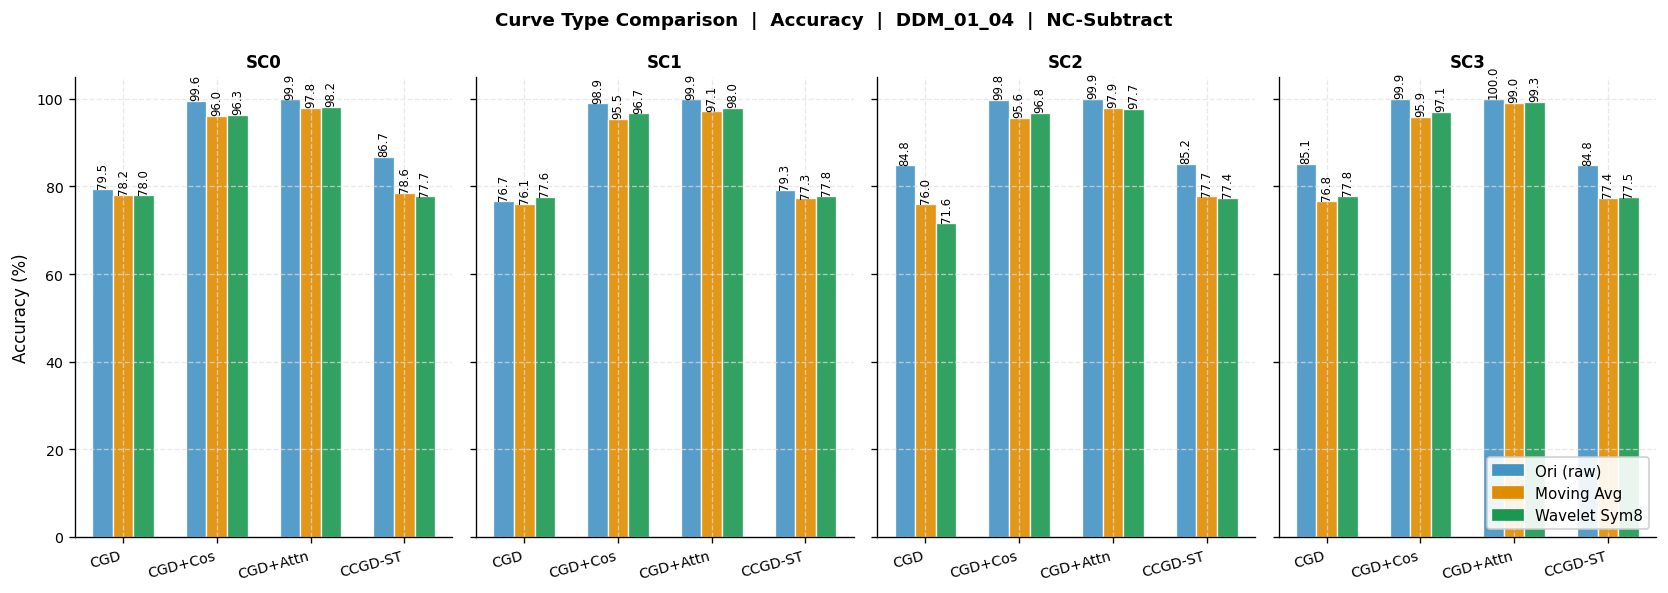

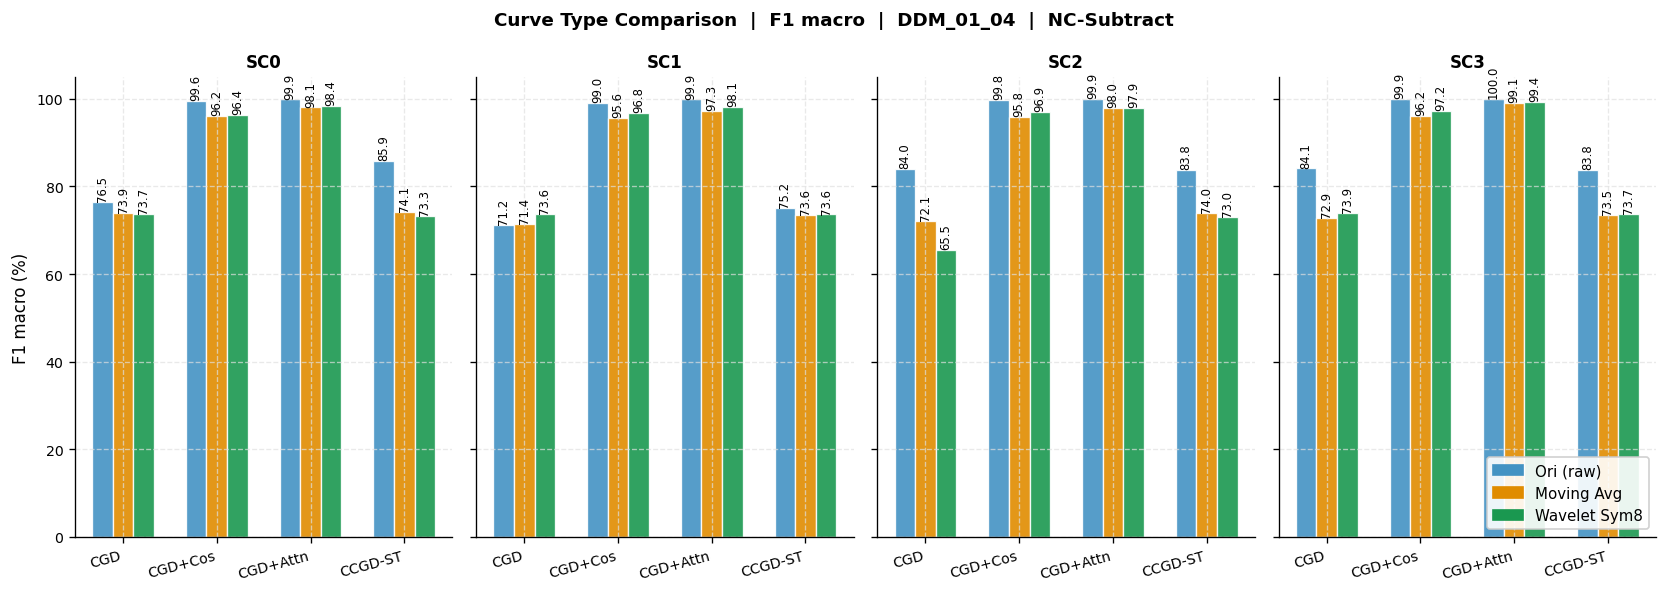

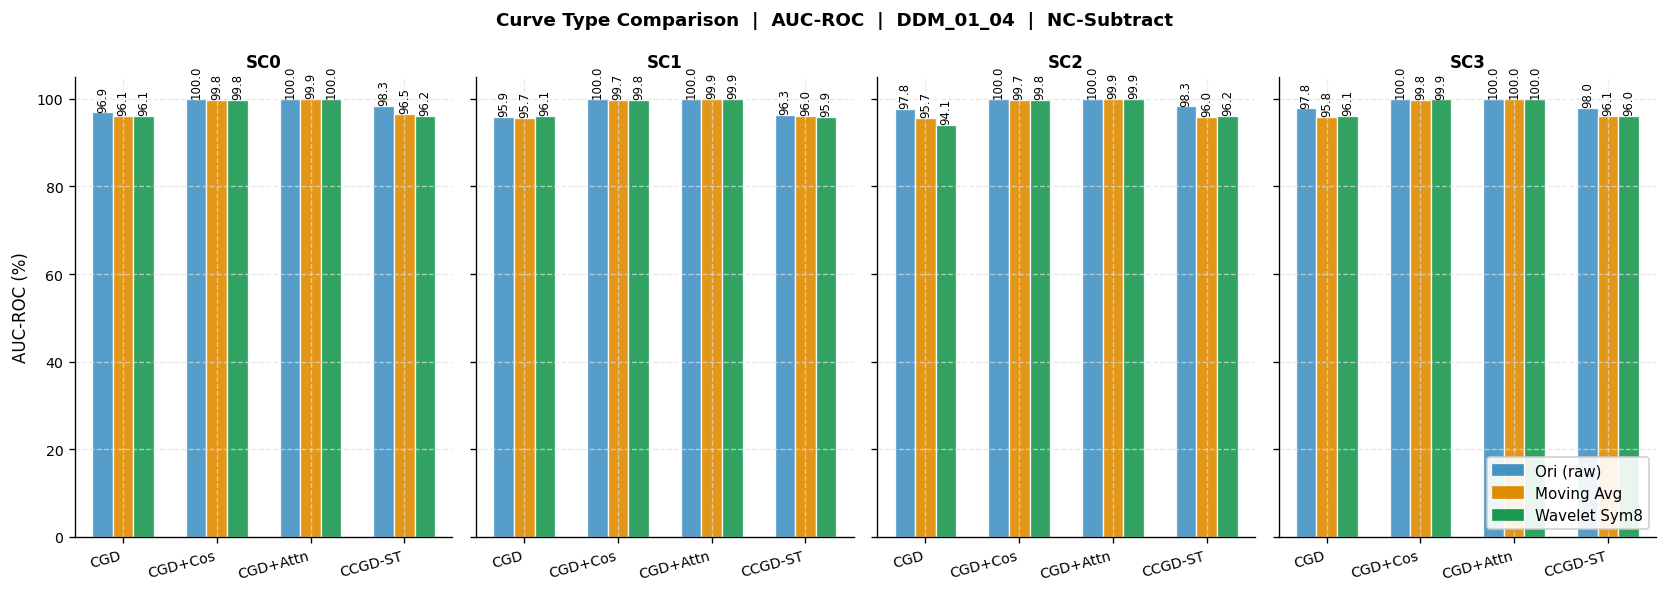

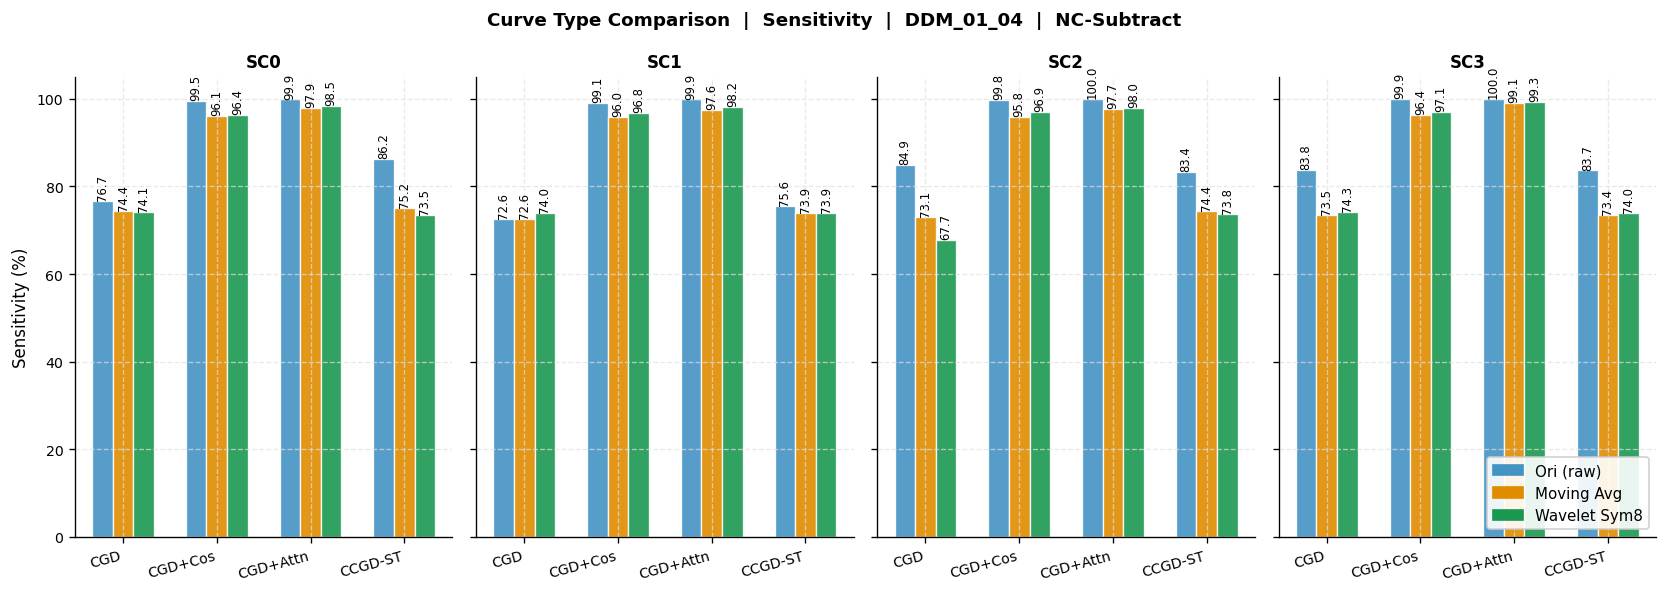

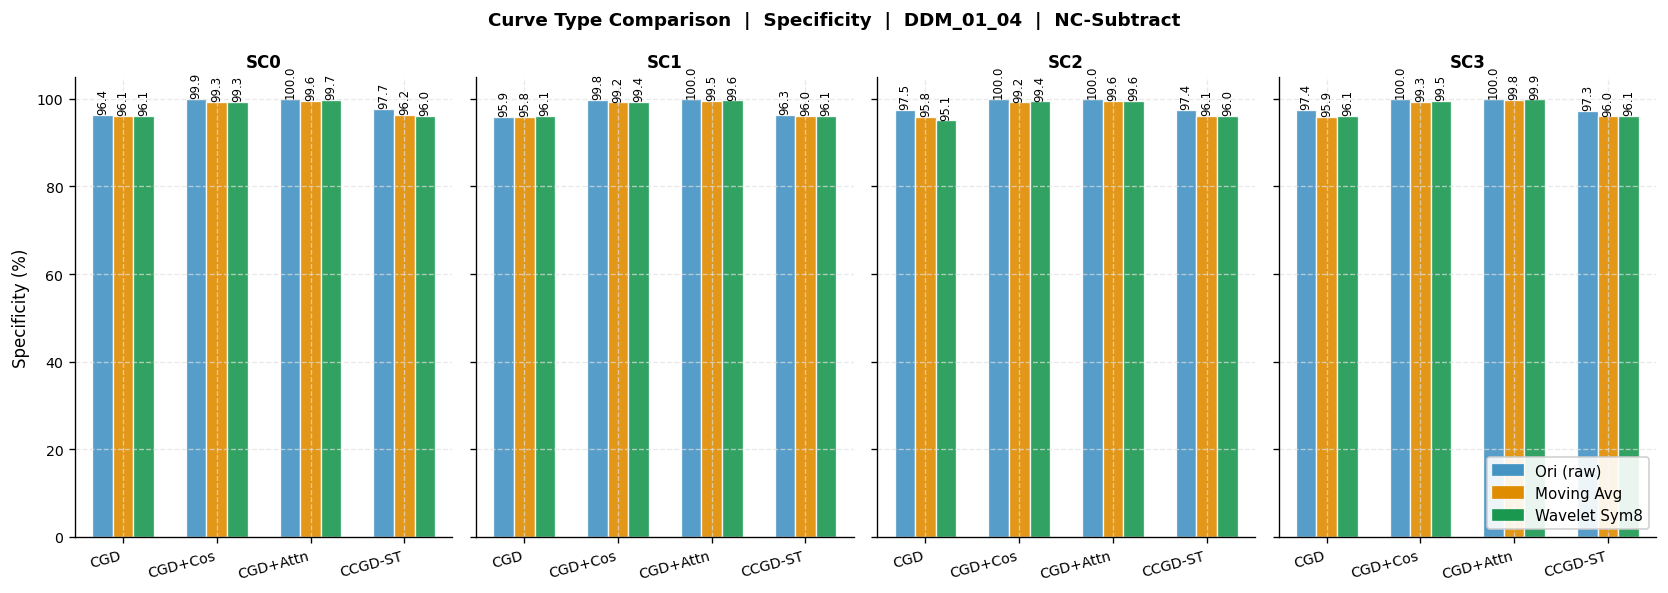

In [ ]:
def plot_curve_comparison(df, dataset, prep, metric='accuracy', figsize=(14, 5)):
    sub = df[(df.dataset == dataset) & (df.preprocessing == prep)]
    curve_keys = list(CURVE_JLIB)   # ['ori', 'avg', 'wavelet']
    n_sc  = len(SC_LEVELS)
    n_fam = len(FAMILIES)

    # One subplot per SC level
    fig, axes = plt.subplots(1, n_sc, figsize=figsize, sharey=True)
    bar_w = 0.22
    x = np.arange(n_fam)

    for ax, sc in zip(axes, SC_LEVELS):
        for ci, curve in enumerate(curve_keys):
            ys = []
            for fam in FAMILIES:
                model = MODEL_KEY[(fam, sc)]
                row = sub[(sub.model == model) & (sub.curve_type == curve)]
                ys.append(row[metric].iloc[0] * 100 if not row.empty else np.nan)
            ys = np.array(ys)
            offset = (ci - 1) * bar_w
            bars = ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
                          color=CURVE_COLORS[curve], label=CURVE_LABELS[curve],
                          edgecolor='white', linewidth=0.8, alpha=0.9)
            for xi, yi in zip(x + offset, ys):
                if not np.isnan(yi):
                    ax.text(xi, yi + 0.2, f'{yi:.1f}', ha='center', va='bottom',
                            fontsize=7, rotation=90)

        ax.set_title(SC_LABELS[sc], fontsize=10, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([FAMILY_LABELS[f] for f in FAMILIES],
                            fontsize=9, rotation=15, ha='right')
        ax.tick_params(labelsize=8.5)
        if ax is axes[0]:
            ax.set_ylabel(f'{METRIC_LABELS[metric]} (%)', fontsize=10)

    handles = [plt.Rectangle((0, 0), 1, 1, color=CURVE_COLORS[c], label=CURVE_LABELS[c])
               for c in curve_keys]
    axes[-1].legend(handles=handles, fontsize=9, loc='lower right', framealpha=0.9)
    fig.suptitle(f'Curve Type Comparison  |  {METRIC_LABELS[metric]}  |  '
                 f'{dataset}  |  {PREP_LABELS[prep]}',
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()


for _m in METRICS:
    plot_curve_comparison(df, 'DDM_01_04', 'nc_subtract', metric=_m)


## 6 · Per-dataset comparison: DDM_01_01 vs DDM_01_04
Shows best metric (accuracy by default) per model for both datasets as a grouped bar chart.
Use the heatmap view below for a full multi-metric view.

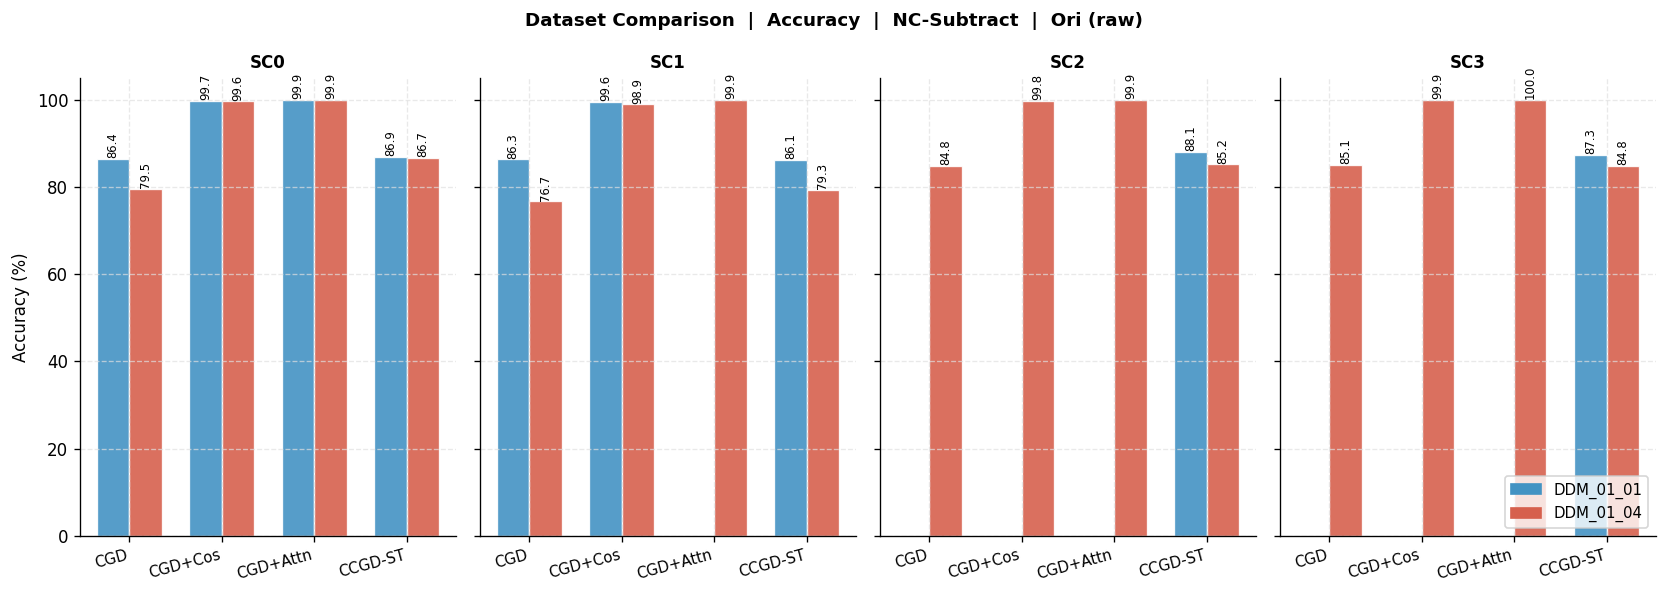

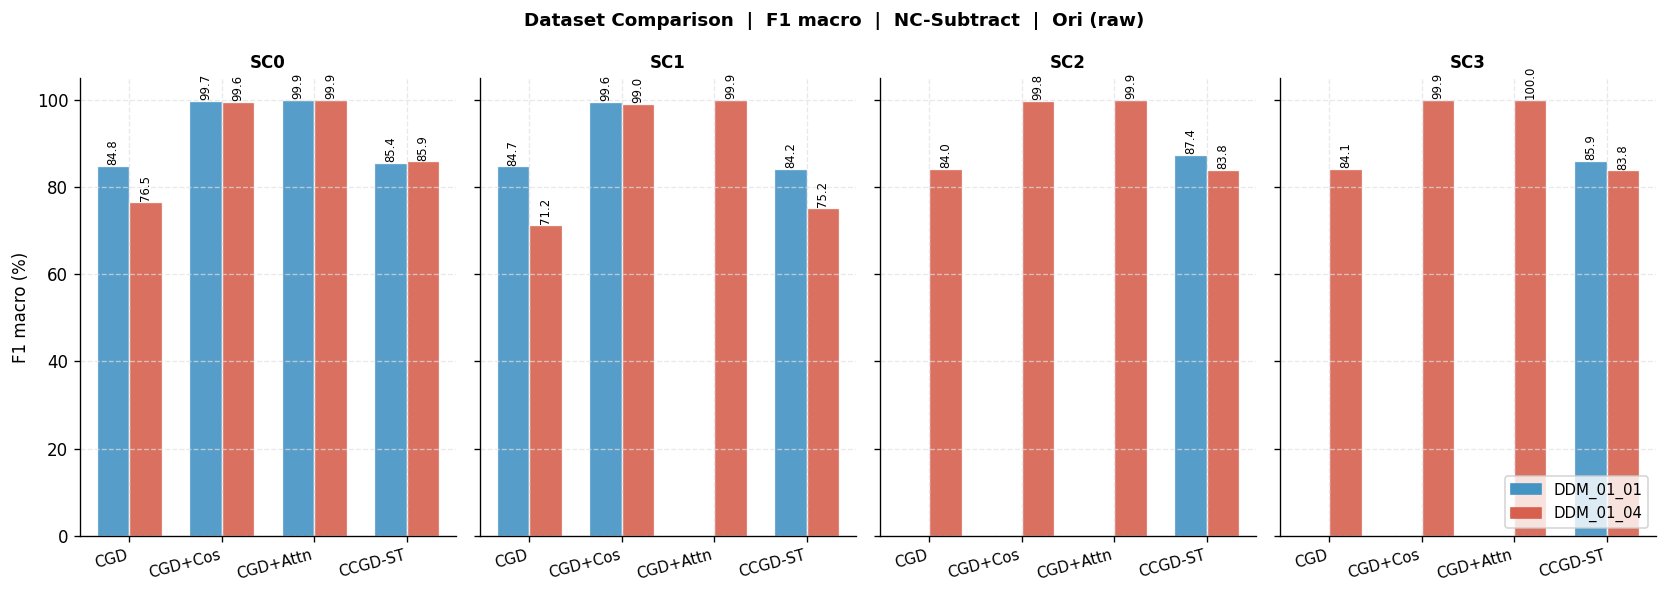

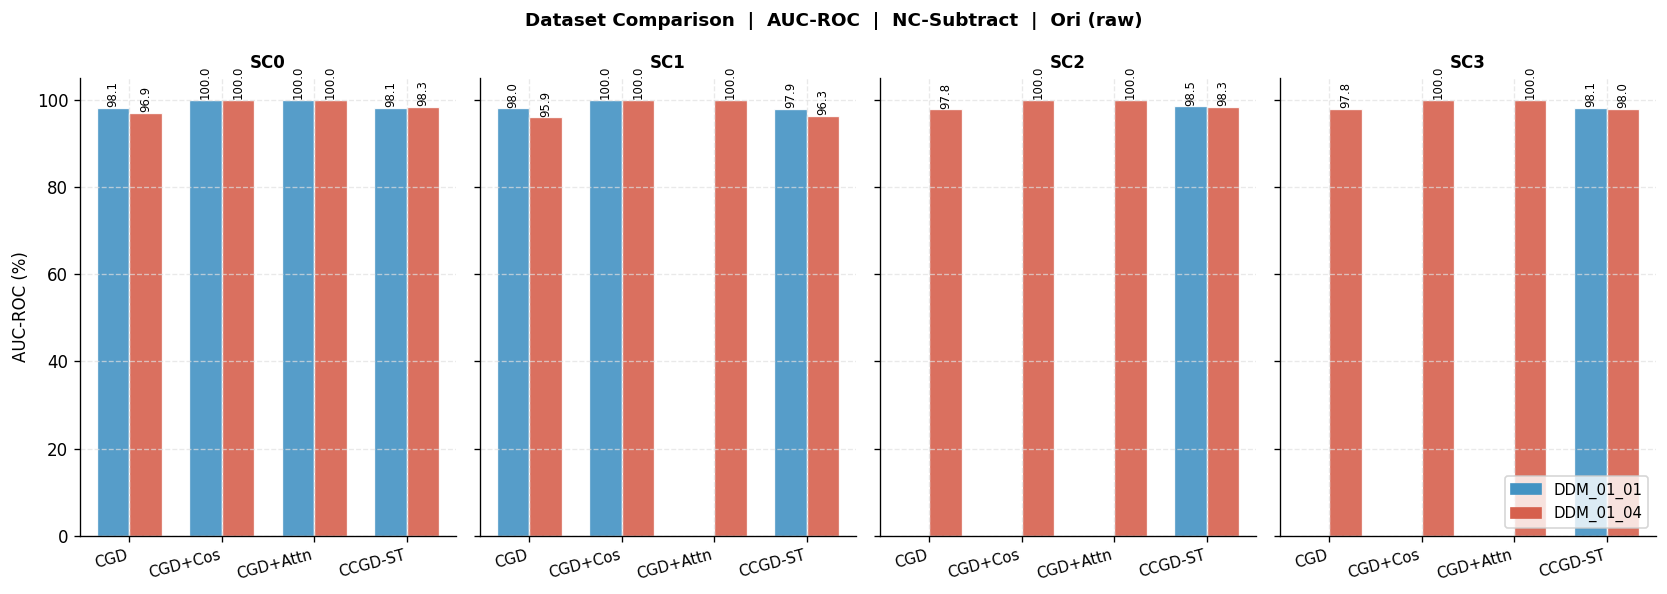

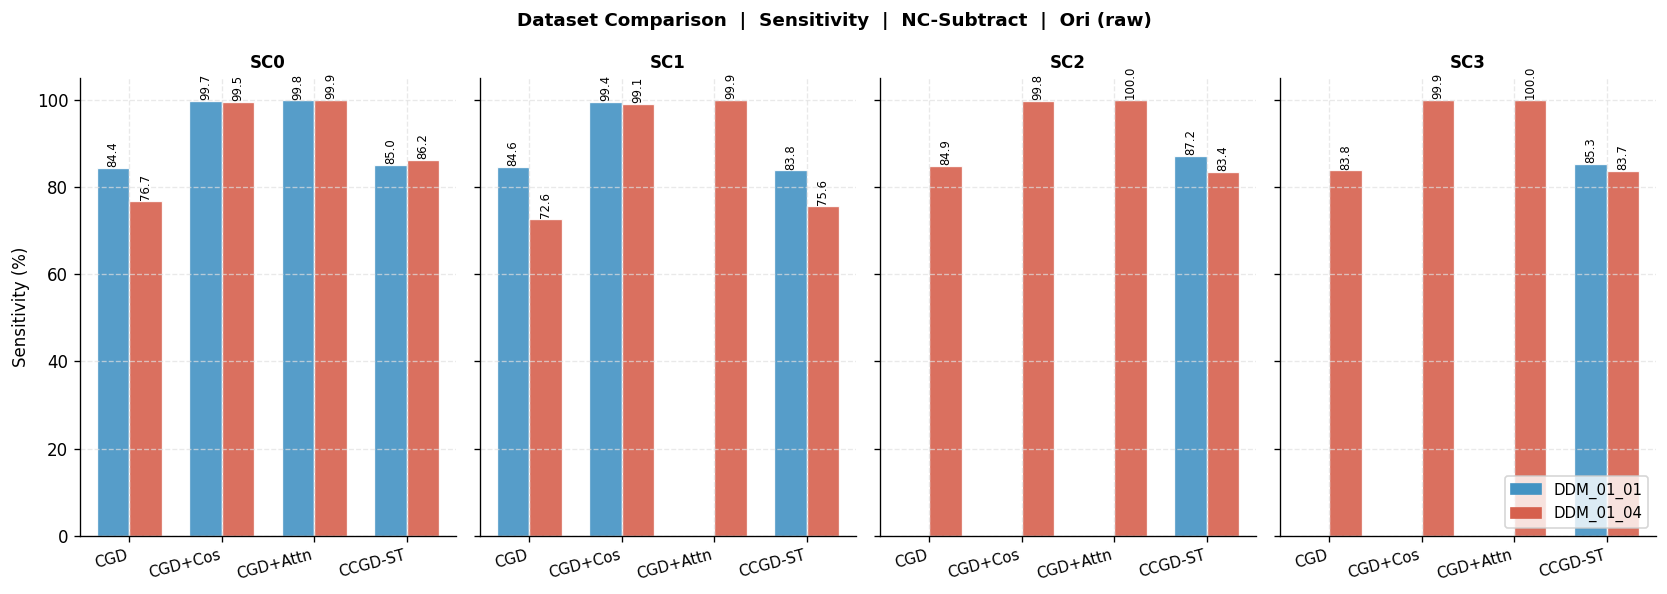

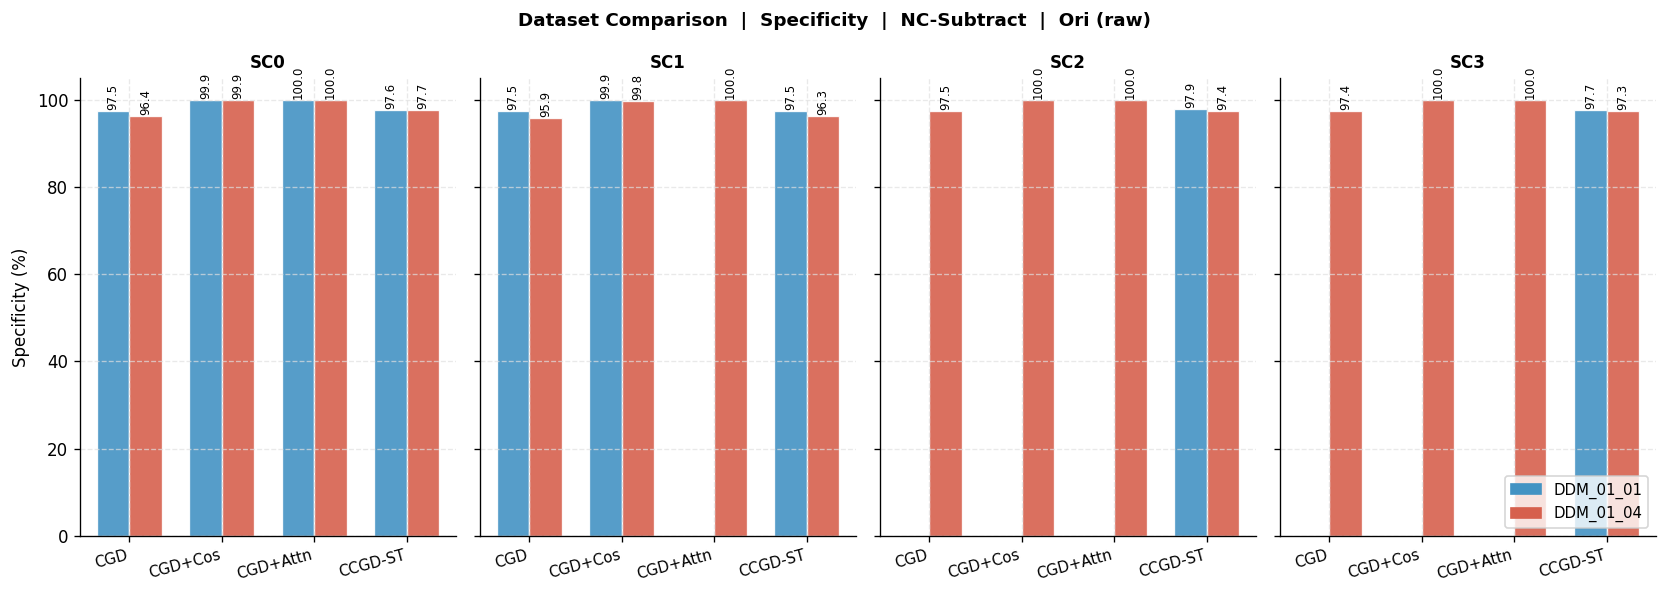

In [ ]:
def plot_dataset_comparison(df, prep, curve, metric='accuracy', figsize=(14, 5)):
    fig, axes = plt.subplots(1, len(SC_LEVELS), figsize=figsize, sharey=True)
    bar_w = 0.35
    x = np.arange(len(FAMILIES))
    ds_colors = {'DDM_01_01': '#4393c3', 'DDM_01_04': '#d6604d'}

    for ax, sc in zip(axes, SC_LEVELS):
        for di, dataset in enumerate(DATASET_NAMES):
            sub = df[(df.dataset == dataset) &
                     (df.preprocessing == prep) &
                     (df.curve_type == curve)]
            ys = np.array([
                (sub[sub.model == MODEL_KEY[(fam, sc)]][metric].iloc[0] * 100
                 if not sub[sub.model == MODEL_KEY[(fam, sc)]].empty else np.nan)
                for fam in FAMILIES
            ])
            offset = (di - 0.5) * bar_w
            ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
                   color=ds_colors[dataset], label=dataset,
                   edgecolor='white', linewidth=0.8, alpha=0.9)
            for xi, yi in zip(x + offset, ys):
                if not np.isnan(yi):
                    ax.text(xi, yi + 0.2, f'{yi:.1f}', ha='center', va='bottom',
                            fontsize=7, rotation=90)

        ax.set_title(SC_LABELS[sc], fontsize=10, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([FAMILY_LABELS[f] for f in FAMILIES],
                            fontsize=9, rotation=15, ha='right')
        if ax is axes[0]:
            ax.set_ylabel(f'{METRIC_LABELS[metric]} (%)', fontsize=10)

    handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=d)
               for d, c in ds_colors.items()]
    axes[-1].legend(handles=handles, fontsize=9, loc='lower right')
    fig.suptitle(f'Dataset Comparison  |  {METRIC_LABELS[metric]}  |  '
                 f'{PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}',
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()


for _m in METRICS:
    plot_dataset_comparison(df, 'nc_subtract', 'ori', metric=_m)


## 7 · Best configuration per model
Across all (dataset, preprocessing, curve_type) combinations — what is each model's peak score per metric?

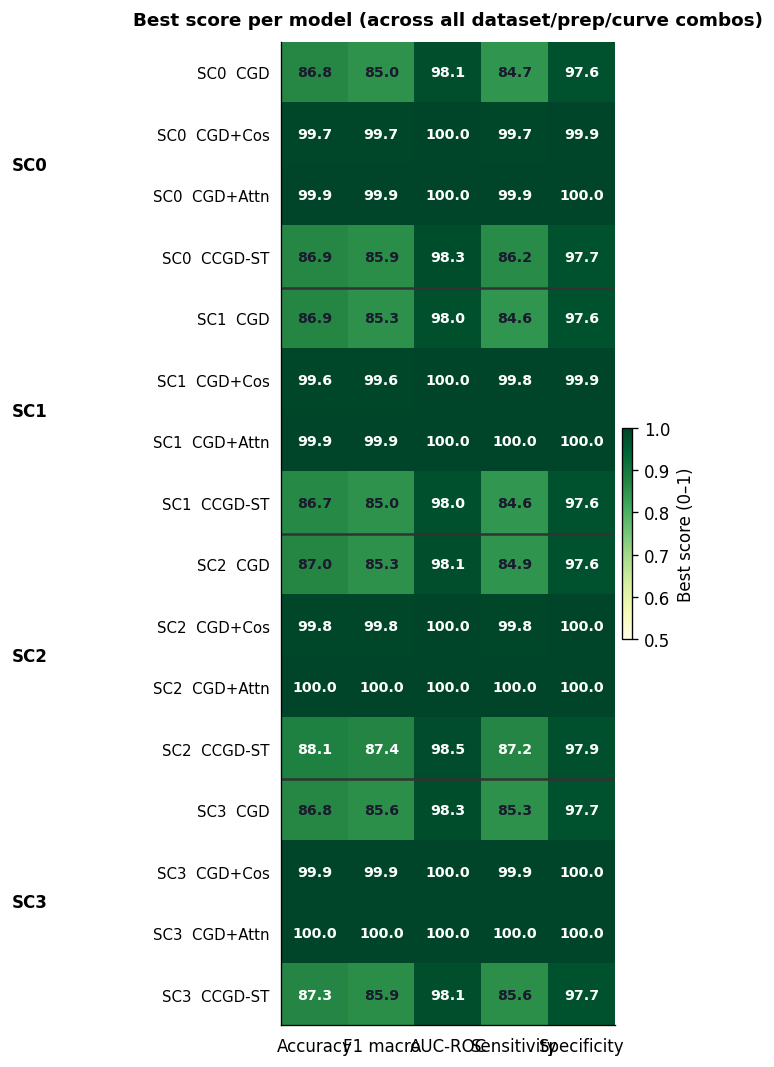

In [ ]:
def best_per_model(df):
    rows = []
    for model in MODELS:
        sub = df[df.model == model]
        row = {'model': model,
               'family': MODEL_TO_FAMILY[model],
               'sc_level': MODEL_TO_SC[model]}
        for metric in METRICS:
            best_row = sub.loc[sub[metric].idxmax()] if not sub.empty else None
            row[metric] = best_row[metric] if best_row is not None else np.nan
            row[f'{metric}_config'] = (
                f"{best_row['dataset']}/{best_row['preprocessing'][0].upper()}/"
                f"{best_row['curve_type']}"
                if best_row is not None else ''
            )
        rows.append(row)
    return pd.DataFrame(rows)

best_df = best_per_model(df)

# Heatmap of best scores
row_order = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
row_labels = [MODEL_ROW_LABEL[m] for m in row_order]
mat = np.array([[best_df[best_df.model == m][metric].iloc[0]
                  for metric in METRICS] for m in row_order])

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(mat, cmap='YlGn', vmin=0.5, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Best score (0–1)')

for ri in range(len(row_order)):
    for ci in range(len(METRICS)):
        v = mat[ri, ci]
        if not np.isnan(v):
            txt_color = 'white' if v > 0.87 else '#1a1a2e'
            ax.text(ci, ri, f'{v*100:.1f}', ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color=txt_color)

for sep in [4, 8, 12]:
    ax.axhline(sep - 0.5, color='#333333', linewidth=1.5)
for si, sc in enumerate(SC_LEVELS):
    ax.text(-0.7, si*4+1.5, SC_LABELS[sc], ha='right', va='center',
            fontsize=10, fontweight='bold', transform=ax.get_yaxis_transform())

ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], fontsize=10)
ax.set_yticks(range(len(row_order)))
ax.set_yticklabels(row_labels, fontsize=9)
ax.tick_params(left=False, bottom=False)
ax.set_title('Best score per model (across all dataset/prep/curve combos)',
             fontsize=11, fontweight='bold', pad=10)
ax.grid(False)
fig.tight_layout(rect=[0.08, 0, 1, 1])
plt.show()

# Leaderboard table
_lb = best_df.copy()
_lb['SC'] = _lb.sc_level.map(SC_LABELS)
_lb['Family'] = _lb.family.map(FAMILY_LABELS)
_lb = _lb.set_index(['SC', 'Family'])[[m for m in METRICS]]
_lb.columns = [METRIC_LABELS[m] for m in METRICS]
display((_lb * 100).round(2).style.background_gradient(cmap='YlGn', vmin=50, vmax=100)
        .format("{:.2f}%")
        .set_caption("Best score per model (all configs)"))
